<div style="text-align:center; border: 2px solid #333; padding: 30px; border-radius: 8px; margin: 20px 0;">

# Министерство науки и высшего образования Российской Федерации
## «Национальный исследовательский университет ИТМО»

---

## Математическая статистика
### Расчётно-графическая работа №2
### Проверка статистических гипотез

---

**Вариант:** A-2  
**Объём выборки:** n = 100  
**Уровень значимости:** α = 0.05  


**Команда:** Ковалев Р.Б, Чекалкин С.А, Дерягин И.Л

</div>



## Содержание

1. [Загрузка данных и первичный анализ](#section1)
2. [Задание 4.2 — Параметрический критерий для двух независимых выборок (X1, X2)](#section2)
3. [Задание 4.3 — Проверка гипотезы о дисперсии нормального распределения (X3)](#section3)
4. [Задание 4.4 — Непараметрический критерий Манна–Уитни (X1, X2)](#section4)
5. [Задание 4.5 — Критерий согласия Пирсона (X4)](#section5)
6. [Итоговый вывод](#section6)


<a id="section1"></a>

## 1. Загрузка данных и первичный анализ

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import t, chi2, mannwhitneyu, ttest_ind, expon

# Настройки отображ
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
np.set_printoptions(precision=4)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [2]:
# подгруз данных
df = pd.read_csv('RGR2_A-2_X1-X4.csv', sep=';')

X1 = df['X1'].values
X2 = df['X2'].values
X3 = df['X3'].values
X4 = df['X4'].values

n = len(df)
alpha = 0.05

print(f"Размер выборки: n = {n}")
print(f"Уровень значимости: α = {alpha}")
print()
print("Первые 5 строк:")
df.head()

Размер выборки: n = 100
Уровень значимости: α = 0.05

Первые 5 строк:


,X1,X2,X3,X4
0,72.5300,66.3600,54.4800,39.9600
1,86.8200,88.8100,56.0400,27.7800
2,80.7200,85.0600,74.6000,9.8400
3,71.0100,79.0000,59.9200,10.7900
4,83.6400,80.5800,66.5500,8.7600


In [3]:
print("ОПИСАТЕЛЬНАЯ СТАТИСТИКА")
desc = df.describe().T
desc.columns = ['n', 'mean', 'std', 'min', '25%', '50% (med)', '75%', 'max']
print(desc.to_string())
print()

for col, arr in zip(['X1', 'X2', 'X3', 'X4'], [X1, X2, X3, X4]):
    print(f"{col}: mean={arr.mean():.4f}, std={arr.std(ddof=1):.4f}, "
          f"var={arr.var(ddof=1):.4f}, min={arr.min():.2f}, max={arr.max():.2f}")

ОПИСАТЕЛЬНАЯ СТАТИСТИКА
          n    mean     std     min     25%  50% (med)     75%      max
X1 100.0000 75.9332 10.5366 45.2000 69.8550    76.7850 83.4075 100.2900
X2 100.0000 80.6168  9.3480 61.8100 74.6225    80.4900 87.5550 108.8100
X3 100.0000 68.5580 10.9810 39.2400 61.8925    69.9950 76.1825  89.1100
X4 100.0000 18.5660 15.2943  0.0500  6.4050    15.7050 28.3625  71.3300

X1: mean=75.9332, std=10.5366, var=111.0199, min=45.20, max=100.29
X2: mean=80.6168, std=9.3480, var=87.3843, min=61.81, max=108.81
X3: mean=68.5580, std=10.9810, var=120.5831, min=39.24, max=89.11
X4: mean=18.5660, std=15.2943, var=233.9145, min=0.05, max=71.33


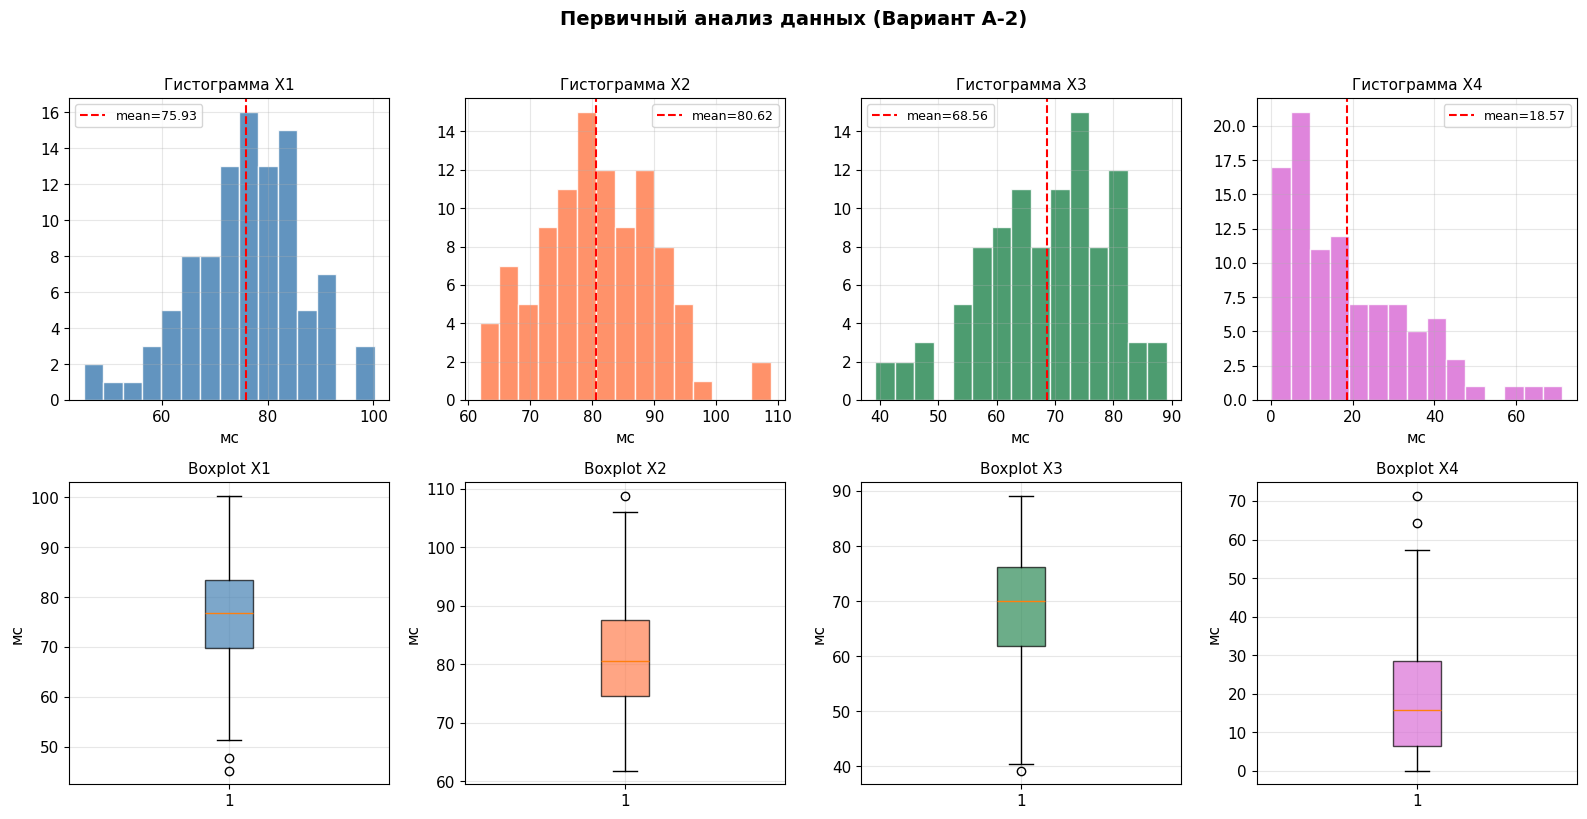

In [4]:
# Визуализация данных
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Первичный анализ данных (Вариант A-2)', fontsize=14, fontweight='bold', y=1.02)

for i, (col, arr) in enumerate(zip(['X1', 'X2', 'X3', 'X4'], [X1, X2, X3, X4])):
    # Гистограмма
    ax1 = axes[0, i]
    ax1.hist(arr, bins=15, color=['steelblue', 'coral', 'seagreen', 'orchid'][i],
             edgecolor='white', alpha=0.85)
    ax1.axvline(arr.mean(), color='red', linestyle='--', lw=1.5, label=f'mean={arr.mean():.2f}')
    ax1.set_title(f'Гистограмма {col}', fontsize=11)
    ax1.set_xlabel('мс')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)

    # Ящик с усами
    ax2 = axes[1, i]
    bp = ax2.boxplot(arr, patch_artist=True,
                     boxprops=dict(facecolor=['steelblue', 'coral', 'seagreen', 'orchid'][i], alpha=0.7))
    ax2.set_title(f'Boxplot {col}', fontsize=11)
    ax2.set_ylabel('мс')
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
# хз надо сохранять или нет, на всякий случай сохраним))
plt.savefig('1.png', bbox_inches='tight', dpi=120)
plt.show()

<a id="section2"></a>

## 2. Задание 4.2 — Параметрический критерий для двух независимых выборок (X1, X2)

### 2.1 Постановка гипотез

Проверяется гипотеза о равенстве математических ожиданий двух независимых нормальных совокупностей.

$$H_0: \mu_1 = \mu_2 \quad \text{(средние равны)}$$
$$H_1: \mu_1 \neq \mu_2 \quad \text{(двусторонняя альтернатива)}$$

**Уровень значимости:** $\alpha = 0{,}05$

### 2.2 Выбор критерия и обоснование

Применяется **двухвыборочный t-критерий Стьюдента** (equal-variance t-test, критерий Фишера–Стьюдента).

**Обоснование применимости:**
- Выборки независимы.
- Объём выброк $n_1 = n_2 = 100$ достаточно велик — по ЦПТ распределение выборочных средних близко к нормальному даже при умеренных отклонениях исходного распределения от нормального.
- Поскольку дисперсии неизвестны предполагаем их равными (проверим с помощью теста Левена).

### 2.3 Ошибка первого рода

> **Ошибка I рода** в данном контексте это ситуация, когда средние времена обработки (в мс) двух групп на самом деле одинаковы, но по результатам выборки мы ошибочно признаём их различными, вероятность такой ошибки равна $\alpha = 0{,}05$, т.е. в 5% случаев мы можем ложно отвергнуть $H_0$.

### 2.4 Формула статистики

$$h = \frac{\bar{X}_1 - \bar{X}_2}{\hat{\sigma} \sqrt{\dfrac{1}{n_1} + \dfrac{1}{n_2}}}, \quad \hat{\sigma}^2 = \frac{(n_1-1)S_1^2 + (n_2-1)S_2^2}{n_1 + n_2 - 2}$$

При $H_0$ статистика $h \sim t(n_1 + n_2 - 2)$.

**Критическая область (двусторонняя):**

$$W = \left(-\infty,\; -t_{n_1+n_2-2,\;1-\alpha/2}\right) \cup \left(t_{n_1+n_2-2,\;1-\alpha/2},\; +\infty\right)$$

In [5]:
print("ЗАДАНИЕ 4.2 — t-критерий для двух независимых выборок")

n1 = len(X1)
n2 = len(X2)
mean1 = X1.mean()
mean2 = X2.mean()
var1  = X1.var(ddof=1)   # S1^2
var2  = X2.var(ddof=1)   # S2^2

print(f"\nВыборочные характеристики:")
print(f"  X1: n1={n1}, mean={mean1:.4f} мс, S1^2={var1:.4f}")
print(f"  X2: n2={n2}, mean={mean2:.4f} мс, S2^2={var2:.4f}")

# Проверка равенства дисперсий — тест Левена
lev_stat, lev_p = stats.levene(X1, X2)
print(f"\nТест Левена (равенство дисперсий): stat={lev_stat:.4f}, p-value={lev_p:.4f}")
if lev_p > alpha:
    print(f"  -> p={lev_p:.4f} > α={alpha}: нет оснований отвергнуть равенство дисперсий.")
    print("  -> Используем t-критерий с объединённой дисперсией (equal_var=True).")
    equal_var_flag = True
else:
    print(f"  -> p={lev_p:.4f} <= α={alpha}: дисперсии значимо различаются.")
    print("  -> Используем критерий Уэлча (equal_var=False).")
    equal_var_flag = False

# Ручной расчёт (объединённая дисперсия)
df_deg = n1 + n2 - 2
sp2 = ((n1 - 1) * var1 + (n2 - 1) * var2) / df_deg   # pooled variance
sp  = np.sqrt(sp2)
h_obs = (mean1 - mean2) / (sp * np.sqrt(1/n1 + 1/n2))
t_crit = t.ppf(1 - alpha/2, df=df_deg)

print(f"\nРасчёт вручную (объединённая дисперсия):")
print(f"  Объединённая дисперсия S^2_pool = {sp2:.4f}, S_pool = {sp:.4f}")
print(f"  Число степеней свободы: df = n1+n2-2 = {df_deg}")
print(f"  Наблюдаемое значение статистики: h_набл = {h_obs:.4f}")
print(f"  Критическое значение: t_{{df, 1-α/2}} = ±{t_crit:.4f}")
print(f"  Критическая область: W = (-inf, -{t_crit:.4f}) ∪ ({t_crit:.4f}, +inf)")

t_stat, p_val = ttest_ind(X1, X2, equal_var=equal_var_flag)
print(f"\nProверка через scipy.stats.ttest_ind:")
print(f"  t-статистика = {t_stat:.4f}")
print(f"  p-value      = {p_val:.6f}")

print("ВЫВОД:")
if abs(h_obs) > t_crit:
    print(f"  |h_набл| = {abs(h_obs):.4f} > t_крит = {t_crit:.4f}")
    print(f"  -> H_0 ОТВЕРГАЕТСЯ при α = {alpha}.")
    print("  -> Средние значения X1 и X2 статистически значимо различаются.")
else:
    print(f"  |h_набл| = {abs(h_obs):.4f} <= t_крит = {t_crit:.4f}")
    print(f"  -> Нет оснований отвергнуть H₀ при α = {alpha}.")
    print("  -> Средние значения X1 и X2 статистически значимо не различаются.")
if p_val < alpha:
    print(f"  (p-value = {p_val:.6f} < α = {alpha} — подтверждает отклонение H_0)")
else:
    print(f"  (p-value = {p_val:.6f} > α = {alpha} — H_0 не отвергается)")

ЗАДАНИЕ 4.2 — t-критерий для двух независимых выборок

Выборочные характеристики:
  X1: n1=100, mean=75.9332 мс, S1^2=111.0199
  X2: n2=100, mean=80.6168 мс, S2^2=87.3843

Тест Левена (равенство дисперсий): stat=0.6392, p-value=0.4249
  -> p=0.4249 > α=0.05: нет оснований отвергнуть равенство дисперсий.
  -> Используем t-критерий с объединённой дисперсией (equal_var=True).

Расчёт вручную (объединённая дисперсия):
  Объединённая дисперсия S^2_pool = 99.2021, S_pool = 9.9600
  Число степеней свободы: df = n1+n2-2 = 198
  Наблюдаемое значение статистики: h_набл = -3.3251
  Критическое значение: t_{df, 1-α/2} = ±1.9720
  Критическая область: W = (-inf, -1.9720) ∪ (1.9720, +inf)

Proверка через scipy.stats.ttest_ind:
  t-статистика = -3.3251
  p-value      = 0.001053
ВЫВОД:
  |h_набл| = 3.3251 > t_крит = 1.9720
  -> H_0 ОТВЕРГАЕТСЯ при α = 0.05.
  -> Средние значения X1 и X2 статистически значимо различаются.
  (p-value = 0.001053 < α = 0.05 — подтверждает отклонение H_0)


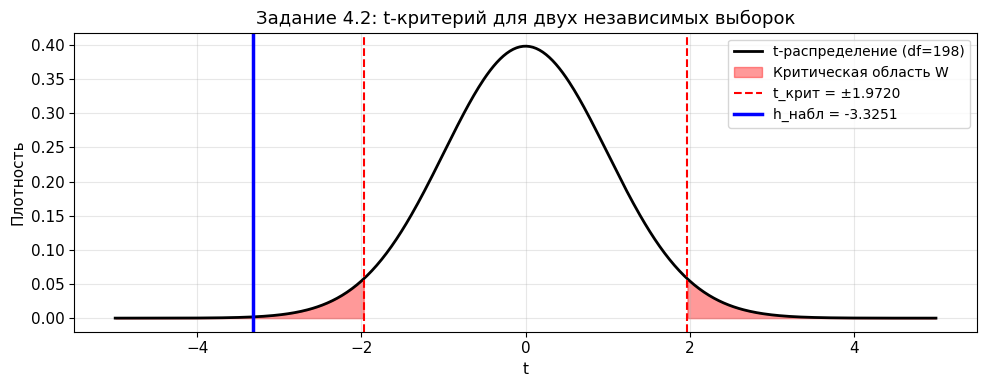

In [6]:
# визуал t-распределения с критической областью
fig, ax = plt.subplots(figsize=(10, 4))
x_range = np.linspace(-5, 5, 500)
y_vals  = t.pdf(x_range, df=df_deg)

ax.plot(x_range, y_vals, 'k-', lw=2, label=f't-распределение (df={df_deg})')

# крит обл
x_right = np.linspace(t_crit, 5, 200)
x_left  = np.linspace(-5, -t_crit, 200)
ax.fill_between(x_right, t.pdf(x_right, df=df_deg), color='red', alpha=0.4, label='Критическая область W')
ax.fill_between(x_left,  t.pdf(x_left,  df=df_deg), color='red', alpha=0.4)

ax.axvline( t_crit, color='red', linestyle='--', lw=1.5, label=f't_крит = ±{t_crit:.4f}')
ax.axvline(-t_crit, color='red', linestyle='--', lw=1.5)
ax.axvline(h_obs,   color='blue', linestyle='-', lw=2.5, label=f'h_набл = {h_obs:.4f}')

ax.set_title('Задание 4.2: t-критерий для двух независимых выборок', fontsize=13)
ax.set_xlabel('t')
ax.set_ylabel('Плотность')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('2.png', bbox_inches='tight', dpi=120)
plt.show()

---

<a id="section3"></a>

## 3. Задание 4.3 — Проверка гипотезы о дисперсии нормального распределения (X3)

### 3.1 Постановка гипотез

для столбца X3 проверяется:

$$H_0: \sigma^2 = 101{,}01$$
$$H_1: \sigma^2 \neq 101{,}01 \quad \text{(двусторонняя альтернатива)}$$

**Уровень значимости:** $\alpha = 0{,}05$

### 3.2 Выбор критерия и обоснование

Применяется **$\chi^2$-критерий для проверки гипотезы о дисперсии** нормального распределения.

**Обоснование:** Математическое ожидание $\mu$ неизвестно; оно оценивается по выборке, выборка X3 предполагается нормально распределённой (объём $n=100$ достаточно велик для того, чтобы незначительные отклонения от нормальности не сказались на результате).

### 3.3 Ошибка первого рода

> **Ошибка I рода** — это когда истинная дисперсия X3 действительно равна $101{,}01$, но по данной выборке мы ошибочно её отвергаем. Вероятность такой ошибки фиксирована на уровне $\alpha = 0{,}05$.

### 3.4 Формула статистики

$$h = \frac{(n-1)S^2}{\sigma_0^2}, \quad S^2 = \frac{1}{n-1}\sum_{i=1}^{n}(X_{3,i} - \bar{X}_3)^2$$

При $H_0$ статистика $h \sim \chi^2(n-1)$.

**Критическая область (двусторонняя):**

$$W = \left(0,\; \chi^2_{n-1,\;\alpha/2}\right) \cup \left(\chi^2_{n-1,\;1-\alpha/2},\; +\infty\right)$$

In [7]:
print("ЗАДАНИЕ 4.3 — χ^2-критерий для дисперсии (X3)")

sigma0_sq = 101.01   # гипотетическая дисперсия
n3   = len(X3)
mean3 = X3.mean()
S3_sq = X3.var(ddof=1)   # выборочная дисперсия
df3  = n3 - 1

print(f"\nХарактеристики выборки X3:")
print(f"  n  = {n3}")
print(f"  mean(X3) = {mean3:.4f} мс")
print(f"  S^2(X3)   = {S3_sq:.4f}  (выборочная дисперсия)")
print(f"  σ²₀      = {sigma0_sq}  (гипотетическая дисперсия по H_0)")
print(f"  df       = n-1 = {df3}")

h_obs3 = (df3 * S3_sq) / sigma0_sq

chi2_lo = chi2.ppf(alpha/2, df=df3)      # левая граница
chi2_hi = chi2.ppf(1 - alpha/2, df=df3)  # правая граница

p_right = 1 - chi2.cdf(h_obs3, df=df3)
p_left  = chi2.cdf(h_obs3, df=df3)
p_val3  = 2 * min(p_left, p_right)

print(f"\nВычисление статистики:")
print(f"  h_набл = (n-1)·S²/σ²₀ = {df3}·{S3_sq:.4f}/{sigma0_sq} = {h_obs3:.4f}")
print(f"  χ²_{{df, α/2}}   = χ²_{{{df3}, 0.025}} = {chi2_lo:.4f}")
print(f"  χ²_{{df, 1-α/2}} = χ²_{{{df3}, 0.975}} = {chi2_hi:.4f}")
print(f"  Критическая область: W = (0, {chi2_lo:.4f}) ∪ ({chi2_hi:.4f}, +∞)")
print(f"  p-value (двусторонний) = {p_val3:.6f}")

print("ВЫВОД:")
in_W = (h_obs3 < chi2_lo) or (h_obs3 > chi2_hi)
if in_W:
    print(f"  h_набл = {h_obs3:.4f} попадает в критическую область W.")
    print(f"  -> H_0 ОТВЕРГАЕТСЯ при α = {alpha}.")
    print(f"  -> Дисперсия X3 статистически значимо отличается от σ²₀ = {sigma0_sq}.")
else:
    print(f"  {chi2_lo:.4f} ≤ h_набл = {h_obs3:.4f} ≤ {chi2_hi:.4f}")
    print(f"  -> h_набл НЕ попадает в критическую область W.")
    print(f"  -> Нет оснований отвергнуть H₀ при α = {alpha}.")
    print(f"  -> Данные не противоречат гипотезе σ^2 = {sigma0_sq}.")
if p_val3 < alpha:
    print(f"  (p-value = {p_val3:.6f} < α — подтверждает отклонение H_0)")
else:
    print(f"  (p-value = {p_val3:.6f} > α — H_0 не отвергается)")

ЗАДАНИЕ 4.3 — χ^2-критерий для дисперсии (X3)

Характеристики выборки X3:
  n  = 100
  mean(X3) = 68.5580 мс
  S^2(X3)   = 120.5831  (выборочная дисперсия)
  σ²₀      = 101.01  (гипотетическая дисперсия по H_0)
  df       = n-1 = 99

Вычисление статистики:
  h_набл = (n-1)·S²/σ²₀ = 99·120.5831/101.01 = 118.1836
  χ²_{df, α/2}   = χ²_{99, 0.025} = 73.3611
  χ²_{df, 1-α/2} = χ²_{99, 0.975} = 128.4220
  Критическая область: W = (0, 73.3611) ∪ (128.4220, +∞)
  p-value (двусторонний) = 0.183279
ВЫВОД:
  73.3611 ≤ h_набл = 118.1836 ≤ 128.4220
  -> h_набл НЕ попадает в критическую область W.
  -> Нет оснований отвергнуть H₀ при α = 0.05.
  -> Данные не противоречат гипотезе σ^2 = 101.01.
  (p-value = 0.183279 > α — H_0 не отвергается)


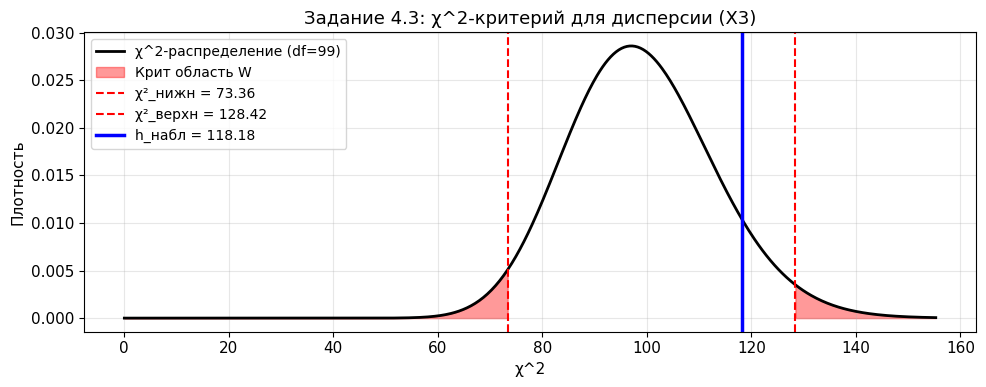

In [8]:
# визуал χ^2-распределения с критической областью
fig, ax = plt.subplots(figsize=(10, 4))
x_range = np.linspace(0.01, df3 + 4*np.sqrt(2*df3), 600)
y_vals  = chi2.pdf(x_range, df=df3)

ax.plot(x_range, y_vals, 'k-', lw=2, label=f'χ^2-распределение (df={df3})')

# крит области
x_left  = np.linspace(0.01, chi2_lo, 200)
x_right = np.linspace(chi2_hi, x_range[-1], 200)
ax.fill_between(x_left,  chi2.pdf(x_left,  df=df3), color='red', alpha=0.4, label='Крит область W')
ax.fill_between(x_right, chi2.pdf(x_right, df=df3), color='red', alpha=0.4)

ax.axvline(chi2_lo, color='red',  linestyle='--', lw=1.5, label=f'χ²_нижн = {chi2_lo:.2f}')
ax.axvline(chi2_hi, color='red',  linestyle='--', lw=1.5, label=f'χ²_верхн = {chi2_hi:.2f}')
ax.axvline(h_obs3,  color='blue', linestyle='-',  lw=2.5, label=f'h_набл = {h_obs3:.2f}')

ax.set_title('Задание 4.3: χ^2-критерий для дисперсии (X3)', fontsize=13)
ax.set_xlabel('χ^2')
ax.set_ylabel('Плотность')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('3.png', bbox_inches='tight', dpi=120)
plt.show()

---

<a id="section4"></a>

## 4. Задание 4.4 — Непараметрический критерий Манна–Уитни (X1, X2)

### 4.1 Постановка гипотез

$$H_0: F_1(x) = F_2(x) \quad \text{(функции распределения совпадают)}$$
$$H_1: F_1(x) \neq F_2(x) \quad \text{(двусторонняя альтернатива)}$$

В содержательном смысле при предположении о сдвиге: $H_0: \theta_1 = \theta_2$ (медианы/локации равны).

**Уровень значимости:** $\alpha = 0{,}05$

### 4.2 Выбор критерия и описание

Применяется **критерий Манна–Уитни (Wilcoxon rank-sum test)**.

**Идея:** Все $n_1 + n_2$ наблюдений объединяются и ранжируются. Вычисляется статистика $U$, основанная на числе «превосходств» элементов одной выборки над другой. При $H_0$ и достаточно большом объёме выборок статистика приближённо нормальна.

**Преимущество перед t-критерием:** не требует нормальности распределений.

### 4.3 Ошибка первого рода

> **Ошибка I рода** — вывод о различии выборок X1 и X2 в ситуации, когда они в действительности взяты из одного закона. Вероятность такой ошибки $= \alpha = 0{,}05$.

In [9]:
print("ЗАДАНИЕ 4.4 — Критерий Манна–Уитни (X1, X2)")

# scipy реализует критерий Манна–Уитни через mannwhitneyu
# alternative=two-sided — двусторонняя альтернатива
U_stat, p_mw = mannwhitneyu(X1, X2, alternative='two-sided')

# описание U-статистики
n1_mw = len(X1)
n2_mw = len(X2)
# максимально возможное значение U
U_max = n1_mw * n2_mw

print(f"\nВыборочные характеристики:")
print(f"  X1: n={n1_mw}, median={np.median(X1):.4f}, mean={X1.mean():.4f}")
print(f"  X2: n={n2_mw}, median={np.median(X2):.4f}, mean={X2.mean():.4f}")
print(f"\nСтатистика Манна–Уитни:")
print(f"  U = {U_stat:.2f}  (из максимума U_max = n1*n2 = {U_max})")
print(f"  p-value (двусторонний) = {p_mw:.6f}")

print("ВЫВОД:")
if p_mw < alpha:
    print(f"  p-value = {p_mw:.6f} < α = {alpha}")
    print("  -> H_( ОТВЕРГАЕТСЯ.")
    print("  -> Выборки X1 и X2 статистически значимо различаются по расположению.")
else:
    print(f"  p-value = {p_mw:.6f} > α = {alpha}")
    print("  -> Нет оснований отвергнуть H_0.")
    print("  -> Выборки X1 и X2 не различаются статистически значимо по расположению.")

print()
print("СРАВНЕНИЕ ВЫВОДОВ 4.2 и 4.4:")
p42_res = p_val   # из задания 4.2
print(f"  Задание 4.2 (t-критерий):       p-value = {p42_res:.6f}")
print(f"  Задание 4.4 (Манна–Уитни):      p-value = {p_mw:.6f}")


# зачем if? потому что круто)
if (p42_res < alpha) == (p_mw < alpha):
    print("\n   Оба критерия приводят к одинаковому выводу.")
    print("  Совпадение объясняется тем, что при нормальном распределении")
    print("  t-критерий является более мощным (UMP), однако Манна–Уитни")
    print("  имеет асимптотическую эффективность ~0.955 по сравнению с t-критерием")
    print("  и поэтому даёт согласованный результат.")
else:
    print("\n   Критерии дают РАЗЛИЧНЫЕ выводы.")
    print("  Расхождение может быть связано с отступлением от нормальности,")
    print("  наличием выбросов, или пограничным значением p-value.")

ЗАДАНИЕ 4.4 — Критерий Манна–Уитни (X1, X2)

Выборочные характеристики:
  X1: n=100, median=76.7850, mean=75.9332
  X2: n=100, median=80.4900, mean=80.6168

Статистика Манна–Уитни:
  U = 3790.00  (из максимума U_max = n1*n2 = 10000)
  p-value (двусторонний) = 0.003124
ВЫВОД:
  p-value = 0.003124 < α = 0.05
  -> H_( ОТВЕРГАЕТСЯ.
  -> Выборки X1 и X2 статистически значимо различаются по расположению.

СРАВНЕНИЕ ВЫВОДОВ 4.2 и 4.4:
  Задание 4.2 (t-критерий):       p-value = 0.001053
  Задание 4.4 (Манна–Уитни):      p-value = 0.003124

   Оба критерия приводят к одинаковому выводу.
  Совпадение объясняется тем, что при нормальном распределении
  t-критерий является более мощным (UMP), однако Манна–Уитни
  имеет асимптотическую эффективность ~0.955 по сравнению с t-критерием
  и поэтому даёт согласованный результат.


/var/folders/x2/76qqzcfd77168fplslpkxctc0000gn/T/ipykernel_45690/3378852276.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([X1, X2], labels=['X1', 'X2'], patch_artist=True,


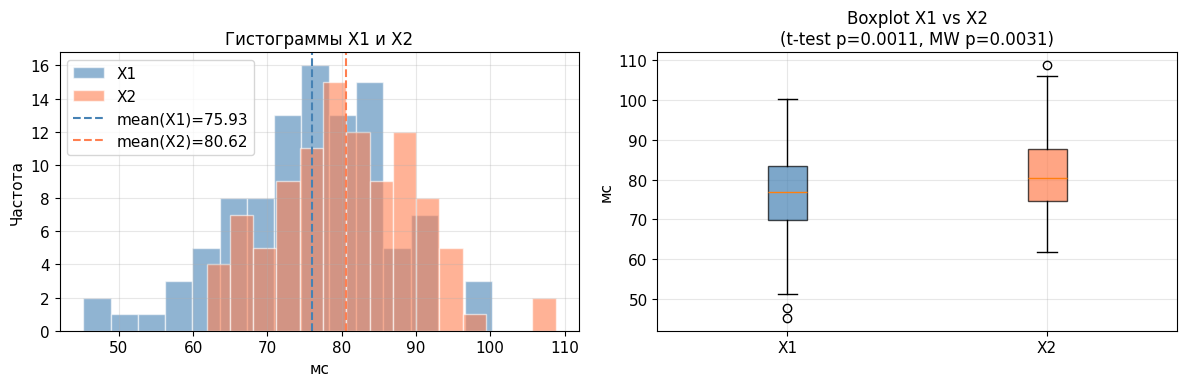

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# гистограммы 
ax = axes[0]
ax.hist(X1, bins=15, alpha=0.6, color='steelblue', label='X1', edgecolor='white')
ax.hist(X2, bins=15, alpha=0.6, color='coral',     label='X2', edgecolor='white')
ax.axvline(X1.mean(), color='steelblue', linestyle='--', lw=1.5, label=f'mean(X1)={X1.mean():.2f}')
ax.axvline(X2.mean(), color='coral',     linestyle='--', lw=1.5, label=f'mean(X2)={X2.mean():.2f}')
ax.set_title('Гистограммы X1 и X2', fontsize=12)
ax.set_xlabel('мс')
ax.set_ylabel('Частота')
ax.legend()
ax.grid(True, alpha=0.3)

# Ящики с усами ( вроде так называется )
ax = axes[1]
bp = ax.boxplot([X1, X2], labels=['X1', 'X2'], patch_artist=True,
                boxprops=dict(alpha=0.7))
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('coral')
ax.set_title(f'Boxplot X1 vs X2\n(t-test p={p_val:.4f}, MW p={p_mw:.4f})', fontsize=12)
ax.set_ylabel('мс')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('4.png', bbox_inches='tight', dpi=120)
plt.show()

---

<a id="section5"></a>

## 5. Задание 4.5 — Критерий согласия Пирсона (X4)

### 5.1 Постановка гипотез

Для столбца X4 проверяется:

$$H_0: X_4 \sim \text{Exp}(\lambda = 0{,}079)$$
$$H_1: X_4 \nsim \text{Exp}(\lambda = 0{,}079)$$

Показательное (экспоненциальное) распределение с параметром $\lambda = 0{,}079$ имеет плотность:
$$f(x) = \lambda e^{-\lambda x} = 0{,}079 \cdot e^{-0{,}079 x}, \quad x \geq 0$$

Математическое ожидание: $\mu = 1/\lambda = 1/0{,}079 \approx 12{,}658$ мс.

**Уровень значимости:** $\alpha = 0{,}05$

### 5.2 Выбор критерия

Применяется **критерий согласия Пирсона ($\chi^2$)**.

### 5.3 Ошибка первого рода

> **Ошибка I рода** — признание несоответствия X4 показательному закону в ситуации, когда данный закон в действительности верен. Вероятность $= \alpha = 0{,}05$.

### 5.4 Формула статистики Пирсона

$$\chi^2_{\text{набл}} = \sum_{k=1}^{m} \frac{(n_k - n p_k)^2}{n p_k}$$

Параметры заданы заранее $\Rightarrow$ число степеней свободы $= m - 1$.

> Примечание: интервалы объединяются при необходимости так, чтобы $n p_k \geq 5$.

In [11]:
print("ЗАДАНИЕ 4.5 — Критерий согласия Пирсона χ^2 (X4)")

lam0 = 0.079      # заданный параметр лямбда
mu_exp = 1 / lam0  # теоретическое МО = 1/лямбда

print(f"\nХарактеристики X4:")
print(f"  n         = {len(X4)}")
print(f"  mean(X4)  = {X4.mean():.4f} мс")
print(f"  std(X4)   = {X4.std(ddof=1):.4f}")
print(f"  min, max  = {X4.min():.2f}, {X4.max():.2f}")
print(f"\nПараметр λ_0   = {lam0}")
print(f"Теор. МО 1/λ_0 = {mu_exp:.4f} мс  (выб. mean = {X4.mean():.4f})")

ЗАДАНИЕ 4.5 — Критерий согласия Пирсона χ^2 (X4)

Характеристики X4:
  n         = 100
  mean(X4)  = 18.5660 мс
  std(X4)   = 15.2943
  min, max  = 0.05, 71.33

Параметр λ_0   = 0.079
Теор. МО 1/λ_0 = 12.6582 мс  (выб. mean = 18.5660)


In [12]:
# выбираем 10 равновероятных интервалов (вероятность каждого == 0.1)
n4  = len(X4)
K   = 10  # начальное число интервалов

# границы интервалов через квантили Exp(lam0)
probs = np.linspace(0, 1, K + 1)
edges = expon.ppf(probs, scale=1/lam0)
edges[0]  = 0          # левая граница 0
edges[-1] = np.inf     # правая бесконечность

print(f"Выбрано K={K} равновероятных интервалов (p_k = 1/K = {1/K:.2f} для каждого).")
print(f"Ожидаемая частота в каждом интервале: np_k = {n4 * (1/K):.1f} >= 5 ")
print(f"\nГраницы интервалов (квантили Exp(λ={lam0})):")
for i, (lo, hi) in enumerate(zip(edges[:-1], edges[1:])):
    hi_str = f"{hi:.4f}" if not np.isinf(hi) else "inf"
    print(f"  Интервал {i+1}: [{lo:.4f}, {hi_str})")

Выбрано K=10 равновероятных интервалов (p_k = 1/K = 0.10 для каждого).
Ожидаемая частота в каждом интервале: np_k = 10.0 >= 5 

Границы интервалов (квантили Exp(λ=0.079)):
  Интервал 1: [0.0000, 1.3337)
  Интервал 2: [1.3337, 2.8246)
  Интервал 3: [2.8246, 4.5149)
  Интервал 4: [4.5149, 6.4661)
  Интервал 5: [6.4661, 8.7740)
  Интервал 6: [8.7740, 11.5986)
  Интервал 7: [11.5986, 15.2402)
  Интервал 8: [15.2402, 20.3726)
  Интервал 9: [20.3726, 29.1466)
  Интервал 10: [29.1466, inf)


In [13]:
# подсчёт наблюдаемых и ожидаемых частот
observed = np.zeros(K, dtype=int)
for i in range(K):
    lo = edges[i]
    hi = edges[i + 1]
    if np.isinf(hi):
        observed[i] = np.sum(X4 >= lo)
    else:
        observed[i] = np.sum((X4 >= lo) & (X4 < hi))

# теоретические вероятности: равновероятные -> p_k = 1/K
pk = np.full(K, 1.0 / K)
expected = n4 * pk

# таблица частот
print("\nТаблица наблюдаемых и ожидаемых частот:")
print(f"{'Интервал':<30} {'n_k':>8} {'np_k':>8} {'(n_k - np_k)^2/np_k':>20}")
chi2_terms = []
for i in range(K):
    lo = edges[i]
    hi = edges[i + 1]
    hi_str = f"{hi:.3f}" if not np.isinf(hi) else "inf"
    term = (observed[i] - expected[i])**2 / expected[i]
    chi2_terms.append(term)
    print(f"  [{lo:.3f}, {hi_str}){'':>10} {observed[i]:>8} {expected[i]:>8.2f} {term:>20.4f}")
print("-" * 65)
print(f"  Итого: {'':>25} {sum(observed):>8} {sum(expected):>8.2f} {sum(chi2_terms):>20.4f}")

# проверка минимальных ожидаемых частот
min_exp = expected.min()
print(f"\nМинимальная ожидаемая частота: {min_exp:.2f}")
if min_exp >= 5:
    print("  все ожидаемые частоты >= 5, объединение интервалов не требуется")
else:
    print("  Некоторые ожидаемые частоты < 5, требуется объединение")


Таблица наблюдаемых и ожидаемых частот:
Интервал                            n_k     np_k  (n_k - np_k)^2/np_k
  [0.000, 1.334)                  5    10.00               2.5000
  [1.334, 2.825)                  6    10.00               1.6000
  [2.825, 4.515)                  4    10.00               3.6000
  [4.515, 6.466)                 10    10.00               0.0000
  [6.466, 8.774)                 12    10.00               0.4000
  [8.774, 11.599)                  6    10.00               1.6000
  [11.599, 15.240)                  6    10.00               1.6000
  [15.240, 20.373)                 14    10.00               1.6000
  [20.373, 29.147)                 14    10.00               1.6000
  [29.147, inf)                 23    10.00              16.9000
-----------------------------------------------------------------
  Итого:                                100   100.00              31.4000

Минимальная ожидаемая частота: 10.00
  все ожидаемые частоты >= 5, объединение инт

In [14]:
# вычисление статистики χ^2 и принятие решения
chi2_obs = sum(chi2_terms)
df_pearson = K - 1   # параметры заданы заранее -> df = m - 1

chi2_crit = chi2.ppf(1 - alpha, df=df_pearson)   # критическое значение (правосторонний)
p_val_pearson = 1 - chi2.cdf(chi2_obs, df=df_pearson)

print(f"Статистика Пирсона:    χ²_набл = {chi2_obs:.4f}")
print(f"Число степеней свободы: df = K-1 = {df_pearson}")
print(f"Критическое значение:   χ²_крит = χ²_{{df, 1-α}} = {chi2_crit:.4f}")
print(f"p-value:                {p_val_pearson:.6f}")
print()
print("КРИТИЧЕСКАЯ ОБЛАСТЬ: W = (χ^2_крит, +inf) = (" + f"{chi2_crit:.4f}, +∞)")
print("ВЫВОД:")
if chi2_obs > chi2_crit:
    print(f"  χ^2_набл = {chi2_obs:.4f} > χ^2_крит = {chi2_crit:.4f}")
    print(f"  -> H_0 ОТВЕРГАЕТСЯ при α = {alpha}.")
    print(f"  -> Данные X4 значимо не согласуются с показательным распределением Exp(λ=0.079).")
else:
    print(f"  χ^2_набл = {chi2_obs:.4f} ≤ χ^2_крит = {chi2_crit:.4f}")
    print(f"  -> Нет оснований отвергнуть H_0 при α = {alpha}.")
    print(f"  -> Данные X4 согласуются с показательным распределением Exp(λ=0.079).")
if p_val_pearson < alpha:
    print(f"  (p-value = {p_val_pearson:.6f} < α — H_0 отвергается)")
else:
    print(f"  (p-value = {p_val_pearson:.6f} > α — H_0 не отвергается)")

Статистика Пирсона:    χ²_набл = 31.4000
Число степеней свободы: df = K-1 = 9
Критическое значение:   χ²_крит = χ²_{df, 1-α} = 16.9190
p-value:                0.000253

КРИТИЧЕСКАЯ ОБЛАСТЬ: W = (χ^2_крит, +inf) = (16.9190, +∞)
ВЫВОД:
  χ^2_набл = 31.4000 > χ^2_крит = 16.9190
  -> H_0 ОТВЕРГАЕТСЯ при α = 0.05.
  -> Данные X4 значимо не согласуются с показательным распределением Exp(λ=0.079).
  (p-value = 0.000253 < α — H_0 отвергается)


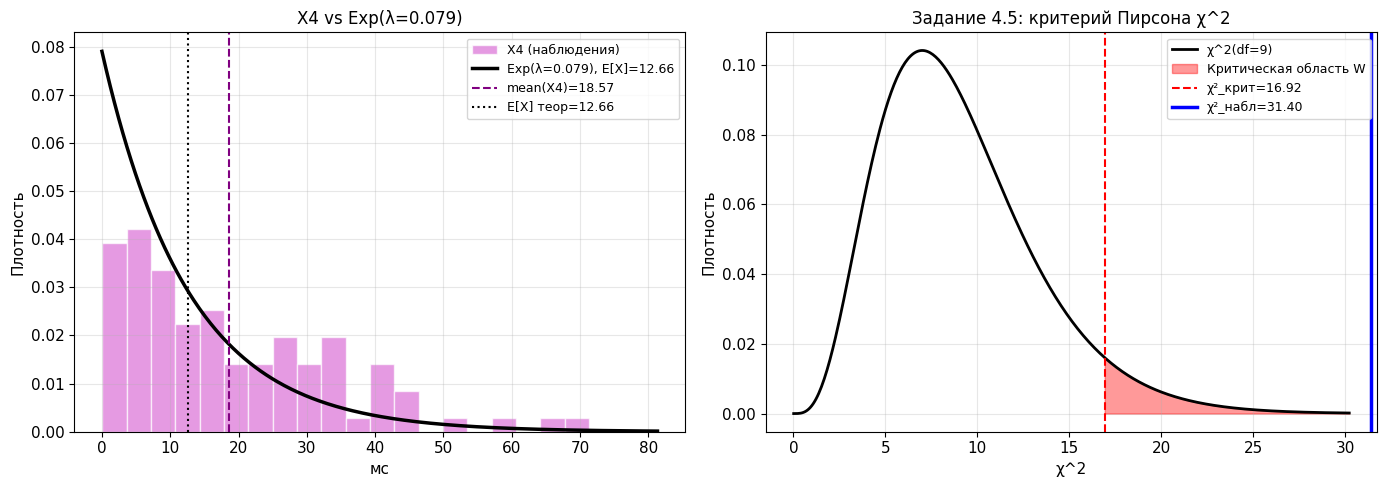

In [15]:
# гистограмма X4 vs теоретическая экспонента + критерий
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x_line = np.linspace(0, X4.max() + 10, 400)
y_exp  = expon.pdf(x_line, scale=1/lam0)

ax.hist(X4, bins=20, density=True, color='orchid', alpha=0.7,
        edgecolor='white', label='X4 (наблюдения)')
ax.plot(x_line, y_exp, 'k-', lw=2.5, label=f'Exp(λ={lam0}), E[X]={mu_exp:.2f}')
ax.axvline(X4.mean(), color='purple', linestyle='--', lw=1.5, label=f'mean(X4)={X4.mean():.2f}')
ax.axvline(mu_exp,    color='black',  linestyle=':',  lw=1.5, label=f'E[X] теор={mu_exp:.2f}')
ax.set_title('X4 vs Exp(λ=0.079)', fontsize=12)
ax.set_xlabel('мс')
ax.set_ylabel('Плотность')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
x_ch = np.linspace(0.01, df_pearson + 5*np.sqrt(2*df_pearson), 400)
y_ch = chi2.pdf(x_ch, df=df_pearson)
ax.plot(x_ch, y_ch, 'k-', lw=2, label=f'χ^2(df={df_pearson})')

x_fill = np.linspace(chi2_crit, x_ch[-1], 300)
ax.fill_between(x_fill, chi2.pdf(x_fill, df=df_pearson),
                color='red', alpha=0.4, label='Критическая область W')
ax.axvline(chi2_crit, color='red',  linestyle='--', lw=1.5, label=f'χ²_крит={chi2_crit:.2f}')
ax.axvline(chi2_obs,  color='blue', linestyle='-',  lw=2.5, label=f'χ²_набл={chi2_obs:.2f}')

ax.set_title('Задание 4.5: критерий Пирсона χ^2', fontsize=12)
ax.set_xlabel('χ^2')
ax.set_ylabel('Плотность')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('5.png', bbox_inches='tight', dpi=120)
plt.show()

---

<a id="section6"></a>

## 6. Итоговый вывод

В данной работе проверялись четыре статистические гипотезы на основе выборок X1–X4 объёма $n = 100$ при уровне значимости $\alpha = 0{,}05$ (вариант A-2).

In [18]:

print("ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")


results = [
    {
        "Задание": "4.2",
        "Столбцы": "X1, X2",
        "Гипотеза H₀": "μ_1 = μ_2",
        "Критерий": "t-критерий Стьюдента",
        "Статистика": f"t = {t_stat:.4f}",
        "p-value": f"{p_val:.4f}",
        "Вывод": "Отвергается" if p_val < alpha else "Не отвергается"
    },
    {
        "Задание": "4.3",
        "Столбцы": "X3",
        "Гипотеза H₀": "σ^2 = 101.01",
        "Критерий": "χ^2-критерий для дисперсии",
        "Статистика": f"χ^2 = {h_obs3:.4f}",
        "p-value": f"{p_val3:.4f}",
        "Вывод": "Отвергается" if p_val3 < alpha else "Не отвергается"
    },
    {
        "Задание": "4.4",
        "Столбцы": "X1, X2",
        "Гипотеза H₀": "F_1(x) = F_2(x)",
        "Критерий": "Манна–Уитни",
        "Статистика": f"U = {U_stat:.1f}",
        "p-value": f"{p_mw:.4f}",
        "Вывод": "Отвергается" if p_mw < alpha else "Не отвергается"
    },
    {
        "Задание": "4.5",
        "Столбцы": "X4",
        "Гипотеза H₀": "X4 ~ Exp(λ=0.079)",
        "Критерий": "Критерий согласия Пирсона χ²",
        "Статистика": f"χ^2 = {chi2_obs:.4f}",
        "p-value": f"{p_val_pearson:.4f}",
        "Вывод": "Отвергается" if p_val_pearson < alpha else "Не отвергается"
    }
]

for r in results:
    print(f"\n  Задание {r['Задание']} ({r['Столбцы']}):")
    print(f"    H₀: {r['Гипотеза H₀']}")
    print(f"    Критерий: {r['Критерий']}")
    print(f"    {r['Статистика']},  p-value = {r['p-value']}")
    verdict = "H₀ ОТВЕРГАЕТСЯ" if r["Вывод"] == "Отвергается" else "H₀ не отвергается"
    print(f"    -> {verdict}")

print()

print("СОДЕРЖАТЕЛЬНАЯ ИНТЕРПРЕТАЦИЯ:")
# Формируем интерпретацию динамически
r42 = "значимо различаются" if p_val < alpha else "статистически значимо не различаются"
r43 = f"значимо {'отличается от' if p_val3 < alpha else 'не отличается от'} σ²₀ = 101.01"
r44 = "значимо различаются" if p_mw < alpha else "значимо не различаются"
r45 = f"{'не согласуется' if p_val_pearson < alpha else 'согласуется'} с Exp(λ=0.079)"

print(f"""
  4.2 (t-критерий, X1/X2): Средние времена {r42}.
  4.3 (χ²-дисперсия, X3):  Дисперсия выборки X3 {r43}.
  4.4 (Манна–Уитни, X1/X2): По непараметрическому критерию выборки {r44}.
       Выводы 4.2 и 4.4 {'совпадают' if (p_val < alpha) == (p_mw < alpha) else 'расходятся'}, 
       что типично: при нормальном распределении t-критерий и Манна–Уитни ведут себя согласованно.
  4.5 (χ² Пирсона, X4):     Выборка X4 {r45}.
""")

ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ

  Задание 4.2 (X1, X2):
    H₀: μ_1 = μ_2
    Критерий: t-критерий Стьюдента
    t = -3.3251,  p-value = 0.0011
    -> H₀ ОТВЕРГАЕТСЯ

  Задание 4.3 (X3):
    H₀: σ^2 = 101.01
    Критерий: χ^2-критерий для дисперсии
    χ^2 = 118.1836,  p-value = 0.1833
    -> H₀ не отвергается

  Задание 4.4 (X1, X2):
    H₀: F_1(x) = F_2(x)
    Критерий: Манна–Уитни
    U = 3790.0,  p-value = 0.0031
    -> H₀ ОТВЕРГАЕТСЯ

  Задание 4.5 (X4):
    H₀: X4 ~ Exp(λ=0.079)
    Критерий: Критерий согласия Пирсона χ²
    χ^2 = 31.4000,  p-value = 0.0003
    -> H₀ ОТВЕРГАЕТСЯ

СОДЕРЖАТЕЛЬНАЯ ИНТЕРПРЕТАЦИЯ:

  4.2 (t-критерий, X1/X2): Средние времена значимо различаются.
  4.3 (χ²-дисперсия, X3):  Дисперсия выборки X3 значимо не отличается от σ²₀ = 101.01.
  4.4 (Манна–Уитни, X1/X2): По непараметрическому критерию выборки значимо различаются.
       Выводы 4.2 и 4.4 совпадают, 
       что типично: при нормальном распределении t-критерий и Манна–Уитни ведут себя согласованно.
  4.

In [ ]:
# сопрано лучший сериал